<a href="https://colab.research.google.com/github/Adimaster1/Adimaster1/blob/main/Basic_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# testing gpu


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")
else:
    print("WARNING: GPU is not enabled.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [3]:
!pip -q install datasets transformers tqdm

import math
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm.auto import tqdm

Importing Datasets


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assignment baseline
CONTEXT_LENGTH = 1024

# Small enough for a Colab GPU
D_MODEL = 384
N_HEADS = 6
N_LAYERS = 6
FFN_DIM = 1536
DROPOUT = 0.1

BATCH_SIZE = 4
GRAD_ACCUMULATION = 4

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
GRAD_CLIP = 1.0

EPOCHS = 5
WARMUP_STEPS = 500

print("Device:", DEVICE)

Device: cuda


In [5]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

print(dataset)
print(dataset["train"][0])

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
{'text': ''}


In [6]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

print(dataset)
print(dataset["train"][0])

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
{'text': ''}


In [7]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

# GPT-2 doesn't have a separate padding token.
tokenizer.pad_token = tokenizer.eos_token

print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Vocabulary size: 50257


In [8]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        add_special_tokens=False
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing WikiText-2"
)

Tokenizing WikiText-2:   0%|          | 0/4358 [00:00<?, ? examples/s]

Tokenizing WikiText-2:   0%|          | 0/36718 [00:00<?, ? examples/s]

Tokenizing WikiText-2:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [9]:
def group_texts(examples):
    # Concatenate all documents
    concatenated = {
        key: sum(examples[key], [])
        for key in examples.keys()
    }

    total_length = len(concatenated["input_ids"])

    # Drop incomplete final sequence
    total_length = (
        total_length // CONTEXT_LENGTH
    ) * CONTEXT_LENGTH

    result = {
        key: [
            values[i:i + CONTEXT_LENGTH]
            for i in range(0, total_length, CONTEXT_LENGTH)
        ]
        for key, values in concatenated.items()
    }

    return result


lm_dataset = tokenized_dataset.map(
    group_texts,
    batched=True,
    desc=f"Creating {CONTEXT_LENGTH}-token sequences"
)

print(lm_dataset)

Creating 1024-token sequences:   0%|          | 0/4358 [00:00<?, ? examples/s]

Creating 1024-token sequences:   0%|          | 0/36718 [00:00<?, ? examples/s]

Creating 1024-token sequences:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 274
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2318
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 240
    })
})


Data Loaders PyTorch

In [10]:
from torch.utils.data import DataLoader

train_dataset = lm_dataset["train"]
val_dataset = lm_dataset["validation"]

train_dataset.set_format(
    type="torch",
    columns=["input_ids"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 580
Validation batches: 60


In [11]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Standard scaled dot-product causal attention
        y = F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=self.attn_dropout.p if self.training else 0.0,
            is_causal=True
        )

        y = y.transpose(1, 2).contiguous()
        y = y.view(B, T, C)

        y = self.out_proj(y)
        y = self.resid_dropout(y)

        return y

In [12]:
class FeedForward(nn.Module):
    def __init__(self, d_model, ffn_dim, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        ffn_dim,
        dropout=0.1
    ):
        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)
        self.attention = CausalSelfAttention(
            d_model,
            n_heads,
            dropout
        )

        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(
            d_model,
            ffn_dim,
            dropout
        )

    def forward(self, x):
        x = x + self.attention(self.ln1(x))
        x = x + self.ffn(self.ln2(x))

        return x

In [14]:
class TransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_seq_len,
        d_model,
        n_heads,
        n_layers,
        ffn_dim,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model
        self.max_seq_len = max_seq_len

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.position_embedding = nn.Embedding(
            max_seq_len,
            d_model
        )

        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                d_model,
                n_heads,
                ffn_dim,
                dropout
            )
            for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)

        self.lm_head = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )

        # Weight tying
        self.lm_head.weight = self.token_embedding.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, targets=None):
        B, T = input_ids.shape

        assert T <= self.max_seq_len

        positions = torch.arange(
            T,
            device=input_ids.device
        )

        token_emb = self.token_embedding(input_ids)
        pos_emb = self.position_embedding(positions)

        x = token_emb + pos_emb
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss

Model Creation


In [15]:
model = TransformerLM(
    vocab_size=tokenizer.vocab_size,
    max_seq_len=CONTEXT_LENGTH,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT
).to(DEVICE)

In [16]:
num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: "
    f"{num_params / 1e6:.2f}M"
)

Trainable parameters: 30.34M


In [17]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(DEVICE)

targets = torch.roll(
    input_ids,
    shifts=-1,
    dims=1
)

logits, loss = model(
    input_ids,
    targets
)

print("Input shape:", input_ids.shape)
print("Logits shape:", logits.shape)
print("Loss:", loss.item())

Input shape: torch.Size([4, 1024])
Logits shape: torch.Size([4, 1024, 50257])
Loss: 10.897333145141602


In [18]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

In [19]:
def train_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    total_tokens = 0

    start_time = time.perf_counter()

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(tqdm(loader)):
        input_ids = batch["input_ids"].to(
            DEVICE,
            non_blocking=True
        )

        targets = torch.roll(
            input_ids,
            shifts=-1,
            dims=1
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            _, loss = model(
                input_ids,
                targets
            )

            loss = loss / GRAD_ACCUMULATION

        loss.backward()

        if (step + 1) % GRAD_ACCUMULATION == 0:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * GRAD_ACCUMULATION
        total_tokens += input_ids.numel()

    elapsed = time.perf_counter() - start_time

    avg_loss = total_loss / len(loader)
    tokens_per_sec = total_tokens / elapsed

    return avg_loss, elapsed, tokens_per_sec

In [20]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for batch in tqdm(loader, desc="Validation"):
        input_ids = batch["input_ids"].to(
            DEVICE,
            non_blocking=True
        )

        targets = torch.roll(
            input_ids,
            shifts=-1,
            dims=1
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            _, loss = model(
                input_ids,
                targets
            )

        total_loss += loss.item() * input_ids.numel()
        total_tokens += input_ids.numel()

    avg_loss = total_loss / total_tokens

    perplexity = math.exp(avg_loss)

    return avg_loss, perplexity

Training the baseline

In [21]:
torch.cuda.empty_cache()

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

In [22]:
history = []

for epoch in range(EPOCHS):

    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")

    train_loss, epoch_time, train_tps = train_epoch(
        model,
        train_loader,
        optimizer
    )

    val_loss, val_ppl = evaluate(
        model,
        val_loader
    )

    if torch.cuda.is_available():
        peak_memory = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )
    else:
        peak_memory = 0

    result = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_ppl": val_ppl,
        "epoch_time": epoch_time,
        "train_tokens_sec": train_tps,
        "peak_memory_gb": peak_memory
    }

    history.append(result)

    print(f"\nTrain loss: {train_loss:.4f}")
    print(f"Val loss:   {val_loss:.4f}")
    print(f"Val PPL:    {val_ppl:.2f}")
    print(f"Epoch time: {epoch_time:.2f} sec")
    print(f"Throughput: {train_tps:.0f} tokens/sec")
    print(f"Peak GPU:   {peak_memory:.2f} GB")


Epoch 1/5


  0%|          | 0/580 [00:00<?, ?it/s]

Validation:   0%|          | 0/60 [00:00<?, ?it/s]


Train loss: 7.9996
Val loss:   7.6448
Val PPL:    2089.79
Epoch time: 59.83 sec
Throughput: 39676 tokens/sec
Peak GPU:   5.32 GB

Epoch 2/5


  0%|          | 0/580 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/60 [00:00<?, ?it/s]


Train loss: 11.0138
Val loss:   11.8530
Val PPL:    140504.17
Epoch time: 61.69 sec
Throughput: 38476 tokens/sec
Peak GPU:   5.32 GB

Epoch 5/5


  0%|          | 0/580 [00:00<?, ?it/s]

Validation:   0%|          | 0/60 [00:00<?, ?it/s]


Train loss: 12.6246
Val loss:   13.4763
Val PPL:    712323.31
Epoch time: 64.73 sec
Throughput: 36672 tokens/sec
Peak GPU:   5.32 GB


  Plot the learning curves

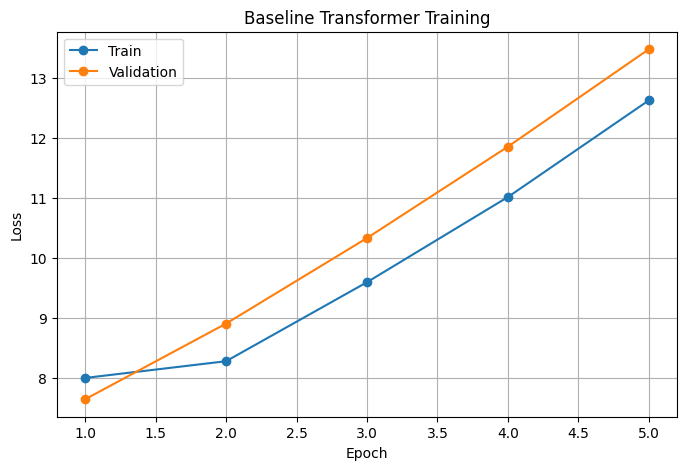

In [23]:
import matplotlib.pyplot as plt

epochs = [x["epoch"] for x in history]
train_losses = [x["train_loss"] for x in history]
val_losses = [x["val_loss"] for x in history]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Train"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Transformer Training")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "context_length": CONTEXT_LENGTH,
            "d_model": D_MODEL,
            "n_heads": N_HEADS,
            "n_layers": N_LAYERS,
            "ffn_dim": FFN_DIM,
            "vocab_size": tokenizer.vocab_size
        },
        "history": history
    },
    "baseline_transformer.pt"
)

print("Checkpoint saved.")

Checkpoint saved.
